In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving HHS_Unaccompanied_Alien_Children_Program.csv to HHS_Unaccompanied_Alien_Children_Program.csv


In [ ]:
df = pd.read_csv("HHS_Unaccompanied_Alien_Children_Program.csv")

In [ ]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [ ]:
df.shape

(1170, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 55.0+ KB


In [ ]:
df.isnull().sum()

,0
Date,450
Children apprehended and placed in CBP custody*,450
Children in CBP custody,450
Children transferred out of CBP custody,450
Children in HHS Care,450
Children discharged from HHS Care,450


In [ ]:
# Check missing values
df.isnull().sum()

,0
Date,450
Children apprehended and placed in CBP custody*,450
Children in CBP custody,450
Children transferred out of CBP custody,450
Children in HHS Care,450
Children discharged from HHS Care,450


In [ ]:
# Check duplicate rows
df.duplicated().sum()

np.int64(449)

In [ ]:
# Check data types
df.dtypes

,0
Date,object
Children apprehended and placed in CBP custody*,float64
Children in CBP custody,float64
Children transferred out of CBP custody,float64
Children in HHS Care,object
Children discharged from HHS Care,float64


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df.dtypes

,0
Date,datetime64[ns]
Children apprehended and placed in CBP custody*,float64
Children in CBP custody,float64
Children transferred out of CBP custody,float64
Children in HHS Care,object
Children discharged from HHS Care,float64


In [ ]:
numeric_columns = [
    'Children apprehended and placed in CBP custody*',
    'Children in CBP custody',
    'Children transferred out of CBP custody',
    'Children in HHS Care',
    'Children discharged from HHS Care'
]

df[numeric_columns] = df[numeric_columns].apply(
    pd.to_numeric, errors='coerce'
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[ns]
 1   Children apprehended and placed in CBP custody*  720 non-null    float64       
 2   Children in CBP custody                          720 non-null    float64       
 3   Children transferred out of CBP custody          720 non-null    float64       
 4   Children in HHS Care                             0 non-null      float64       
 5   Children discharged from HHS Care                720 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 55.0 KB


In [ ]:
# Transfer Efficiency Ratio
df['Transfer Efficiency Ratio'] = (
    df['Children transferred out of CBP custody'] /
    df['Children in CBP custody']
)

# Discharge Effectiveness
df['Discharge Effectiveness'] = (
    df['Children discharged from HHS Care'] /
    df['Children in HHS Care']
)

# Pipeline Throughput
df['Pipeline Throughput'] = (
    df['Children transferred out of CBP custody'] +
    df['Children discharged from HHS Care']
) / (
    df['Children apprehended and placed in CBP custody*'] +
    df['Children transferred out of CBP custody']
)

In [ ]:
df[['Date',
    'Transfer Efficiency Ratio',
    'Discharge Effectiveness',
    'Pipeline Throughput']].head()

,Date,Transfer Efficiency Ratio,Discharge Effectiveness,Pipeline Throughput
0,2025-12-21,0.611111,NaN,1.470588
1,2025-12-18,0.120000,NaN,1.294118
2,2025-12-17,0.354839,NaN,1.166667
3,2025-12-16,0.277778,NaN,1.043478
4,2025-12-15,0.214286,NaN,0.800000


In [ ]:
df['Children in HHS Care'] = (
    df['Children in HHS Care']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df['Children in HHS Care'] = pd.to_numeric(
    df['Children in HHS Care'],
    errors='coerce'
)

In [ ]:
df['Discharge Effectiveness'] = (
    df['Children discharged from HHS Care'] /
    df['Children in HHS Care']
)

In [ ]:
df[['Date',
    'Children in HHS Care',
    'Children discharged from HHS Care',
    'Discharge Effectiveness']].head()

,Date,Children in HHS Care,Children discharged from HHS Care,Discharge Effectiveness
0,2025-12-21,NaN,14.0,NaN
1,2025-12-18,NaN,16.0,NaN
2,2025-12-17,NaN,10.0,NaN
3,2025-12-16,NaN,9.0,NaN
4,2025-12-15,NaN,7.0,NaN


In [ ]:
# Reload original dataset correctly
df = pd.read_csv(
    "HHS_Unaccompanied_Alien_Children_Program.csv",
    thousands=','
)

# Convert Date
df['Date'] = pd.to_datetime(df['Date'])

# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[ns]
 1   Children apprehended and placed in CBP custody*  720 non-null    float64       
 2   Children in CBP custody                          720 non-null    float64       
 3   Children transferred out of CBP custody          720 non-null    float64       
 4   Children in HHS Care                             720 non-null    float64       
 5   Children discharged from HHS Care                720 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 55.0 KB


In [ ]:
df[['Children in HHS Care',
    'Children discharged from HHS Care']].head()

,Children in HHS Care,Children discharged from HHS Care
0,2484.0,14.0
1,2472.0,16.0
2,2481.0,10.0
3,2468.0,9.0
4,2470.0,7.0


In [ ]:
# Basic Statistics
df.describe()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
count,720,720.000000,720.000000,720.000000,720.000000,720.000000
mean,2024-07-06 05:29:59.999999744,93.523611,171.494444,128.668056,6061.275000,173.406944
min,2023-01-12 00:00:00,0.000000,7.000000,0.000000,1972.000000,0.000000
25%,2023-10-16 18:00:00,12.000000,36.000000,14.000000,2467.750000,19.750000
50%,2024-07-05 12:00:00,99.000000,193.000000,157.000000,6406.500000,181.000000
75%,2025-03-25 06:00:00,147.250000,263.250000,199.250000,8010.250000,267.000000
max,2025-12-21 00:00:00,333.000000,531.000000,440.000000,11516.000000,505.000000
std,NaN,72.646625,126.354965,97.322012,2833.070109,125.702841


In [ ]:
# Missing Values Check

df.isnull().sum()

,0
Date,450
Children apprehended and placed in CBP custody*,450
Children in CBP custody,450
Children transferred out of CBP custody,450
Children in HHS Care,450
Children discharged from HHS Care,450


In [ ]:
# Check rows where all values are missing

df[df.isnull().all(axis=1)].shape

(450, 6)

In [ ]:
# Remove completely blank rows

df = df.dropna(how='all').reset_index(drop=True)

# Check dataset shape after removing blank rows
df.shape

(720, 6)

In [ ]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort data by date
df = df.sort_values('Date').reset_index(drop=True)

# Check the updated data
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0
1,2023-01-22,32.0,49.0,39.0,7122.0,227.0
2,2023-01-23,32.0,50.0,39.0,7280.0,181.0
3,2023-01-24,47.0,42.0,47.0,7433.0,175.0
4,2023-01-25,20.0,22.0,41.0,7538.0,180.0


In [ ]:
# Check duplicate rows

df.duplicated().sum()

np.int64(0)

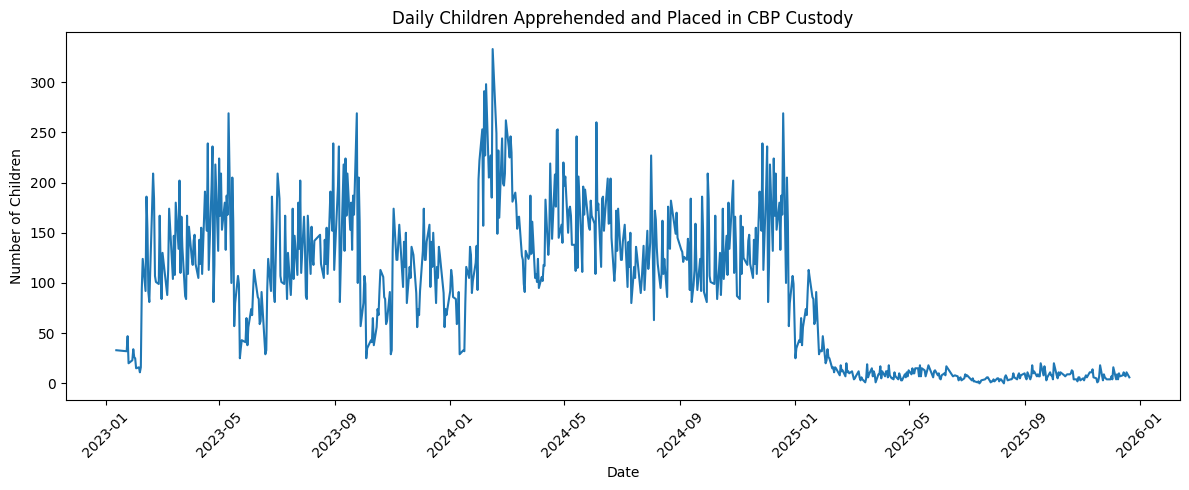

In [ ]:
# Daily trend of children apprehended

plt.figure(figsize=(12, 5))

plt.plot(
    df['Date'],
    df['Children apprehended and placed in CBP custody*']
)

plt.title('Daily Children Apprehended and Placed in CBP Custody')
plt.xlabel('Date')
plt.ylabel('Number of Children')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

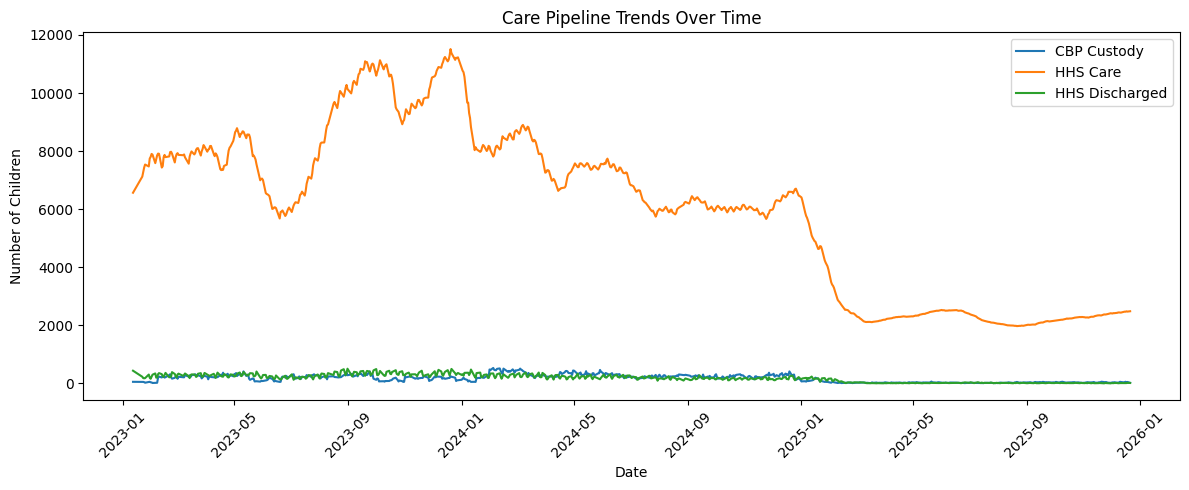

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    df['Date'],
    df['Children in CBP custody'],
    label='CBP Custody'
)

plt.plot(
    df['Date'],
    df['Children in HHS Care'],
    label='HHS Care'
)

plt.plot(
    df['Date'],
    df['Children discharged from HHS Care'],
    label='HHS Discharged'
)

plt.title('Care Pipeline Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Children')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

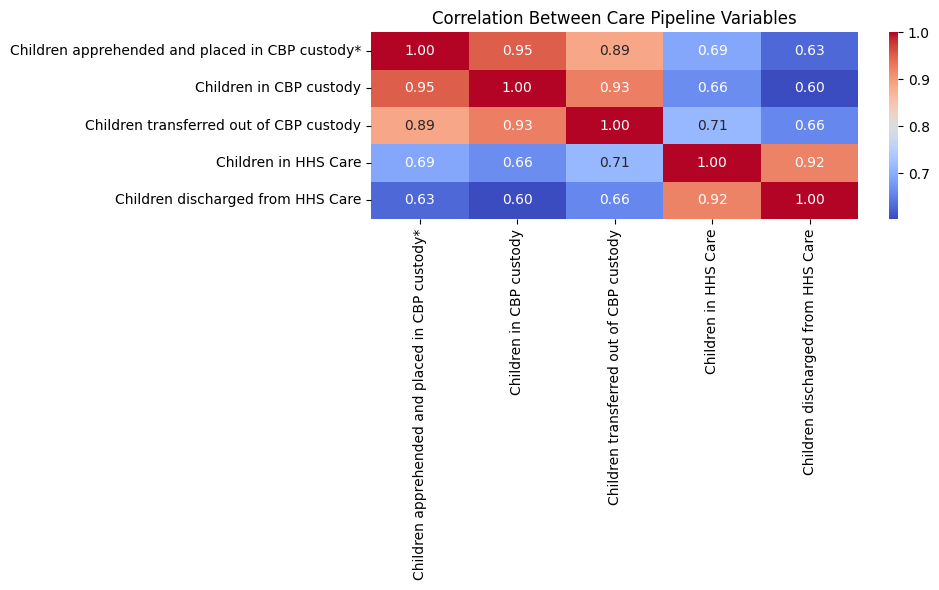

In [ ]:
# Correlation Analysis

plt.figure(figsize=(10, 6))

corr = df[
    [
        'Children apprehended and placed in CBP custody*',
        'Children in CBP custody',
        'Children transferred out of CBP custody',
        'Children in HHS Care',
        'Children discharged from HHS Care'
    ]
].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Between Care Pipeline Variables')
plt.tight_layout()
plt.show()

In [ ]:
# Monthly Trend Analysis

df['Month'] = df['Date'].dt.to_period('M')

monthly_data = df.groupby('Month')[
    [
        'Children in CBP custody',
        'Children transferred out of CBP custody',
        'Children in HHS Care',
        'Children discharged from HHS Care'
    ]
].mean()

monthly_data.head()

,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Month,,,,
2023-01,43.875000,34.500000,7369.625000,232.000000
2023-02,171.315789,138.789474,7795.789474,272.789474
2023-03,245.105263,178.894737,7945.368421,282.894737
2023-04,250.190476,188.904762,7842.666667,269.904762
2023-05,216.954545,164.636364,8187.136364,284.363636


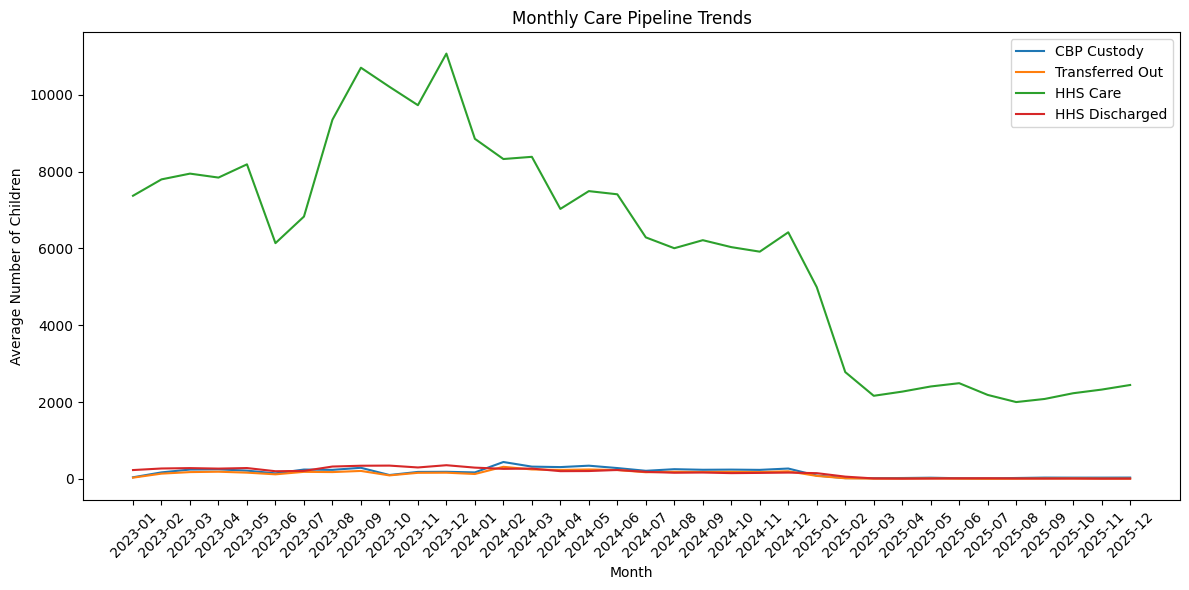

In [ ]:
# Monthly Trend Graph

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_data.index.astype(str),
    monthly_data['Children in CBP custody'],
    label='CBP Custody'
)

plt.plot(
    monthly_data.index.astype(str),
    monthly_data['Children transferred out of CBP custody'],
    label='Transferred Out'
)

plt.plot(
    monthly_data.index.astype(str),
    monthly_data['Children in HHS Care'],
    label='HHS Care'
)

plt.plot(
    monthly_data.index.astype(str),
    monthly_data['Children discharged from HHS Care'],
    label='HHS Discharged'
)

plt.title('Monthly Care Pipeline Trends')
plt.xlabel('Month')
plt.ylabel('Average Number of Children')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Backlog Accumulation Rate

df['Total Active Care'] = (
    df['Children in CBP custody'] +
    df['Children in HHS Care']
)

df['Backlog Accumulation Rate'] = (
    df['Total Active Care'].diff() /
    df['Total Active Care'].shift(1)
)

df[['Date', 'Total Active Care', 'Backlog Accumulation Rate']].head()

,Date,Total Active Care,Backlog Accumulation Rate
0,2023-01-12,6619.0,NaN
1,2023-01-22,7171.0,0.083396
2,2023-01-23,7330.0,0.022173
3,2023-01-24,7475.0,0.019782
4,2023-01-25,7560.0,0.011371


In [ ]:
# Weekday Analysis

df['Weekday'] = df['Date'].dt.day_name()

weekday_data = df.groupby('Weekday')[
    [
        'Children in CBP custody',
        'Children transferred out of CBP custody',
        'Children in HHS Care',
        'Children discharged from HHS Care'
    ]
].mean()

weekday_data

,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Weekday,,,,
Friday,111.000000,110.000000,4296.500000,144.000000
Monday,167.944828,123.731034,6063.517241,157.558621
Sunday,169.392308,130.061538,5875.015385,206.138462
Thursday,171.210884,133.414966,6128.789116,205.687075
Tuesday,173.557047,124.859060,6082.436242,136.114094
Wednesday,175.870748,131.673469,6158.829932,166.013605


In [ ]:
# Outcome Stability Score

monthly_discharge = df.groupby('Month')['Discharge Effectiveness'].mean()

mean_discharge = monthly_discharge.mean()
std_discharge = monthly_discharge.std()

outcome_stability_score = 1 - (std_discharge / mean_discharge)

print("Outcome Stability Score:", outcome_stability_score)

KeyError: 'Column not found: Discharge Effectiveness'

In [ ]:
print(df.columns.tolist())

['Date', 'Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children in HHS Care', 'Children discharged from HHS Care', 'Month', 'Total Active Care', 'Backlog Accumulation Rate', 'Weekday']


In [ ]:
df['Month'] = pd.to_datetime(df['Date']).dt.month

In [ ]:
['Discharge Effectiveness']

['Discharge Effectiveness']

In [ ]:
for col in df.columns:
    print(repr(col))

'Date'
'Children apprehended and placed in CBP custody*'
'Children in CBP custody'
'Children transferred out of CBP custody'
'Children in HHS Care'
'Children discharged from HHS Care'
'Month'
'Total Active Care'
'Backlog Accumulation Rate'
'Weekday'


In [ ]:
# Calculate Discharge Effectiveness
df['Discharge Effectiveness'] = (
    df['Children discharged from HHS Care'] /
    df['Children in HHS Care']
) * 100

print("Average Discharge Effectiveness:")
print(df['Discharge Effectiveness'].mean())

Average Discharge Effectiveness:
2.3737002796523012


In [ ]:
# Create Month from Date
df['Month'] = pd.to_datetime(df['Date']).dt.month

# Monthly average discharge effectiveness
monthly_discharge = df.groupby('Month')['Discharge Effectiveness'].mean()

# Calculate stability
mean_discharge = monthly_discharge.mean()
std_discharge = monthly_discharge.std()

outcome_stability_score = 1 - (std_discharge / mean_discharge)

print("Outcome Stability Score:", outcome_stability_score)

Outcome Stability Score: 0.8570991846981806


In [ ]:
print(df['Discharge Effectiveness'].mean())

2.3737002796523012


In [ ]:
# Final EDA Insights

print("===== FINAL EDA INSIGHTS =====")


print("\n2. Average Discharge Effectiveness:")
print(df['Discharge Effectiveness'].mean())

print("\n3. Average Pipeline Throughput:")
print(df['Pipeline Throughput'].mean())

print("\n4. Average Backlog Accumulation Rate:")
print(df['Backlog Accumulation Rate'].mean())

print("\n5. Highest CBP Custody:")
print(df['Children in CBP custody'].max())

print("\n6. Highest HHS Care:")
print(df['Children in HHS Care'].max())

print("\n7. Highest HHS Discharges:")
print(df['Children discharged from HHS Care'].max())

print("\n8. Outcome Stability Score:")
print(outcome_stability_score)

===== FINAL EDA INSIGHTS =====

2. Average Discharge Effectiveness:
2.3737002796523012

3. Average Pipeline Throughput:


KeyError: 'Pipeline Throughput'

In [ ]:
# Save the cleaned dataset for Streamlit

df.to_csv("UAC_Care_Transition_Analysis.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [ ]:
from google.colab import files
files.download("UAC_Care_Transition_Analysis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

# Page Configuration
st.set_page_config(
    page_title="UAC Care Transition Analytics",
    page_icon="📊",
    layout="wide"
)

# Load Dataset
df = pd.read_csv("UAC_Care_Transition_Analysis.csv")

# Date Conversion
df["Date"] = pd.to_datetime(df["Date"])

# Title
st.title("Care Transition Efficiency & Placement Outcome Analytics")
st.write("Analysis of CBP to HHS care transition and discharge outcomes.")

# Sidebar
st.sidebar.header("Filters")

min_date = df["Date"].min().date()
max_date = df["Date"].max().date()

start_date = st.sidebar.date_input(
    "Start Date",
    min_date
)

end_date = st.sidebar.date_input(
    "End Date",
    max_date
)

filtered_df = df[
    (df["Date"].dt.date >= start_date) &
    (df["Date"].dt.date <= end_date)
]

# KPI Calculations
transfer_efficiency = filtered_df[
    "Transfer Efficiency Ratio"
].mean()

discharge_effectiveness = filtered_df[
    "Discharge Effectiveness"
].mean()

pipeline_throughput = filtered_df[
    "Pipeline Throughput"
].mean()

backlog_rate = filtered_df[
    "Backlog Accumulation Rate"
].mean()

# KPI Cards
st.subheader("Key Performance Indicators")

col1, col2, col3, col4 = st.columns(4)

col1.metric(
    "Transfer Efficiency",
    f"{transfer_efficiency:.2%}"
)

col2.metric(
    "Discharge Effectiveness",
    f"{discharge_effectiveness:.2%}"
)

col3.metric(
    "Pipeline Throughput",
    f"{pipeline_throughput:.2%}"
)

col4.metric(
    "Backlog Accumulation",
    f"{backlog_rate:.2%}"
)

# Pipeline Trends
st.subheader("Care Pipeline Trends")

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    filtered_df["Date"],
    filtered_df["Children in CBP custody"],
    label="CBP Custody"
)

ax.plot(
    filtered_df["Date"],
    filtered_df["Children in HHS Care"],
    label="HHS Care"
)

ax.plot(
    filtered_df["Date"],
    filtered_df["Children discharged from HHS Care"],
    label="HHS Discharged"
)

ax.set_xlabel("Date")
ax.set_ylabel("Number of Children")
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()

st.pyplot(fig)

ModuleNotFoundError: No module named 'streamlit'

In [ ]:
streamlit run app.py

SyntaxError: invalid syntax (3737097518.py, line 1)

In [ ]:
pip install streamlit pandas matplotlib

In [ ]:
streamlit run app.py

In [ ]:
# Bottleneck Analysis
st.subheader("Bottleneck Analysis")

bottleneck_data = pd.DataFrame({
    "Stage": [
        "CBP Custody",
        "Transferred Out of CBP",
        "HHS Care",
        "HHS Discharged"
    ],
    "Average": [
        filtered_df["Children in CBP custody"].mean(),
        filtered_df["Children transferred out of CBP custody"].mean(),
        filtered_df["Children in HHS Care"].mean(),
        filtered_df["Children discharged from HHS Care"].mean()
    ]
})

st.bar_chart(
    bottleneck_data.set_index("Stage")
)

st.dataframe(bottleneck_data, use_container_width=True)

In [ ]:
# Outcome Trends

st.subheader("Outcome Trends")

fig2, ax2 = plt.subplots(figsize=(12, 5))

ax2.plot(
    filtered_df["Date"],
    filtered_df["Transfer Efficiency Ratio"],
    label="Transfer Efficiency"
)

ax2.plot(
    filtered_df["Date"],
    filtered_df["Discharge Effectiveness"],
    label="Discharge Effectiveness"
)

ax2.set_xlabel("Date")
ax2.set_ylabel("Ratio")
ax2.set_title("Transfer and Discharge Outcome Trends")
ax2.legend()

plt.xticks(rotation=45)
plt.tight_layout()

st.pyplot(fig2)

In [ ]:
# Threshold Alerts

st.subheader("Threshold Alerts")

transfer_threshold = st.sidebar.slider(
    "Transfer Efficiency Alert Threshold",
    0.0, 1.0, 0.50
)

discharge_threshold = st.sidebar.slider(
    "Discharge Effectiveness Alert Threshold",
    0.0, 1.0, 0.50
)

if transfer_efficiency < transfer_threshold:
    st.warning(
        f"⚠️ Transfer Efficiency is below the selected threshold: "
        f"{transfer_threshold:.0%}"
    )
else:
    st.success("✅ Transfer Efficiency is above the selected threshold.")

if discharge_effectiveness < discharge_threshold:
    st.warning(
        f"⚠️ Discharge Effectiveness is below the selected threshold: "
        f"{discharge_threshold:.0%}"
    )
else:
    st.success("✅ Discharge Effectiveness is above the selected threshold.")